# Explainability using SHAP

## importing the model and dataset

In [1]:
import pandas as pd 
import mlflow
import mlflow.sklearn

RUN_ID = "a084293413704d02967935b576fb8f5c"

MODEL_URI = f"runs:/{RUN_ID}/model"

mlflow.set_tracking_uri("file:///D:/projects/home_default/mlruns/")
model = mlflow.sklearn.load_model(MODEL_URI)

df = pd.read_csv('../Dataset/Loan_default.csv')

d:\projects\home_default\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)


In [3]:
# train test split
from sklearn.model_selection import train_test_split

X = df.drop('Default', axis=1)
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

In [5]:
print(model)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_scaled', 'passthrough',
                                                  ['Income', 'LoanAmount',
                                                   'CreditScore']),
                                                 ('num_unscaled', 'passthrough',
                                                  ['Age', 'MonthsEmployed',
                                                   'NumCreditLines',
                                                   'LoanTerm']),
                                                 ('binary',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes'],
                                                                             ['No',
                                                                              'Yes'],
                                                        

## Finding the Shap for lightGBM model

d:\projects\home_default\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


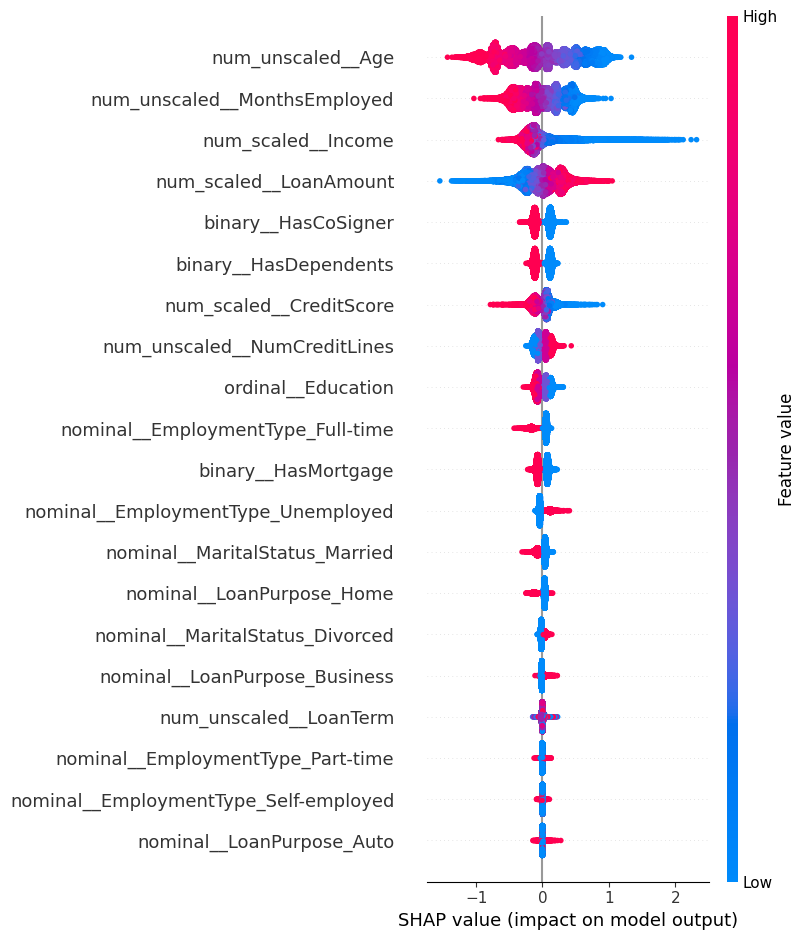

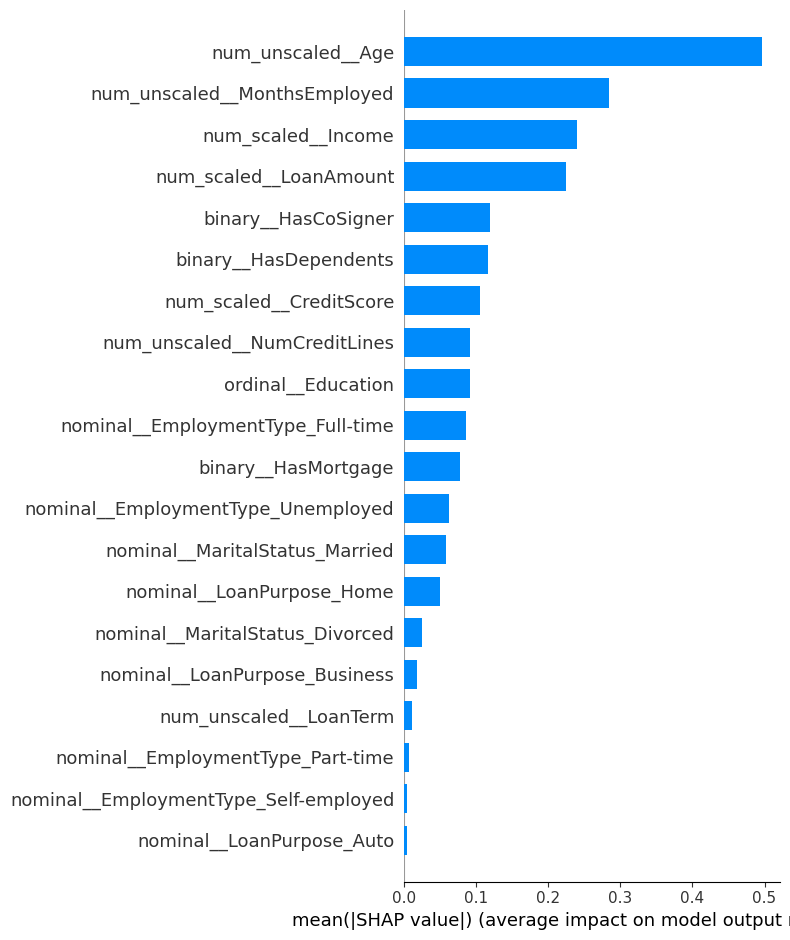

In [9]:
import shap
import lightgbm as lgb
import pandas as pd

lgbm_model = model.named_steps['model']
preprocessor = model.named_steps["preprocess"]   # adjust name
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_transformed)
shap_values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(shap_values_to_plot, X_test_transformed_df)
shap.summary_plot(shap_values_to_plot, X_test_transformed_df, plot_type="bar")